# Othello-GPT: Probing and Activation Intervention

Can a transformer trained only to predict Othello moves recover the board internally? We use TDHook to read and edit the released Othello-GPT model, following [*Linear Latent World Models in Simple Transformers*](https://arxiv.org/abs/2310.07582).

We decode an internal board, compare move predictions before and after a counterfactual intervention, and evaluate the layer-by-game-length pattern. The main result is a probability-map comparison exported from a composed workflow.

## Load the model and games

The model, linear probes, and 100 synthetic games are downloaded on first use and then cached locally. The introductory decoding and diagnostics use the released TransformerLens model; the behavioral comparison and sweep explicitly load Hazineh's released model and probes.

### Workflow and figure exports

The schematic summarizes the artifact dependencies; the executable `Workflow`
definitions appear below. Model configuration is fixed, while per-example results
pass between stages through TensorDict keys.

Every figure is displayed here and exported to `figures/` in the working
directory as an editable SVG and a 300-dpi PNG. The exported files use the same data as the inline figures.

In [1]:
from __future__ import annotations
import importlib.util
import json
import sys
import types
import urllib.request
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import torch
from huggingface_hub import hf_hub_download
from IPython.display import Markdown, display
from matplotlib.colors import ListedColormap
from tensordict import NonTensorData, TensorDict
from tensordict.nn import TensorDictModule
from torch.nn import functional as F
from transformer_lens import HookedTransformer, HookedTransformerConfig
from tdhook.interventions import (
    EarlyStoppingConfig,
    InterventionObjective,
    InterventionSpec,
    OptimizerConfig,
    optimize_intervention,
)
from tdhook.latent import ActivationCaching, SteeringVectors
from tdhook.targets import Target

In [2]:
tutorial_path = Path("docs/source/notebooks/tutorials")
tutorial_dir = next(
    (root / tutorial_path for root in (Path.cwd(), *Path.cwd().parents) if (root / tutorial_path).is_dir()), Path.cwd()
)
sys.path.insert(0, str(tutorial_dir))
from notebook_figures import STYLE, draw_board, finish_figure, workflow_figure  # noqa: E402

plt.rcParams.update(STYLE)

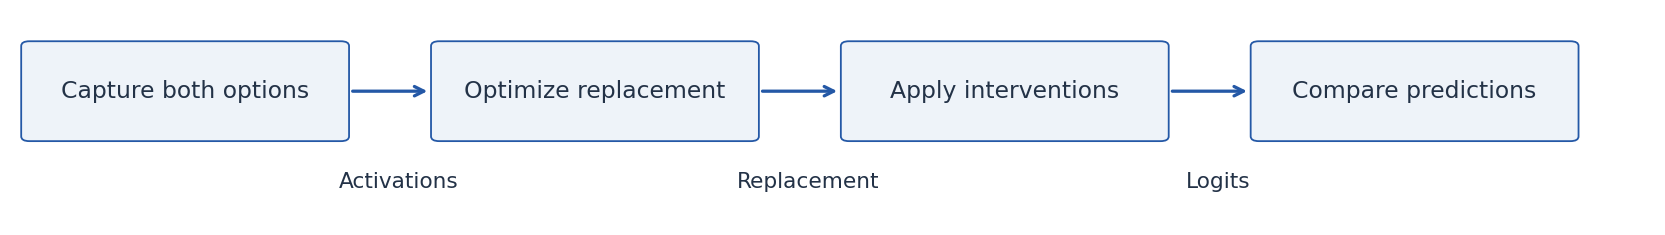

In [3]:
workflow_figure(
    ["Capture both options", "Optimize replacement", "Apply interventions", "Compare predictions"],
    ["Activations", "Replacement", "Logits"],
    "othello-research-reproduction-workflow",
);

In [4]:
from tdhook.workflow import Workflow

OTHELLO_REVISION = "f23bb5696cf30b93bd8af8a391ee33fc3aac417e"
HF_REVISION = "905ca1a68b9f7dff77adc56af1962e5f6fcac274"
CACHE = Path.home() / ".cache" / "tdhook" / "othello-reproduction"
CACHE.mkdir(parents=True, exist_ok=True)
BASE = f"https://raw.githubusercontent.com/likenneth/othello_world/{OTHELLO_REVISION}"
ASSETS = {
    "main_linear_probe.pth": f"{BASE}/mechanistic_interpretability/main_linear_probe.pth",
    "board_seqs_int_small.npy": f"{BASE}/mechanistic_interpretability/board_seqs_int_small.npy",
    "board_seqs_string_small.npy": f"{BASE}/mechanistic_interpretability/board_seqs_string_small.npy",
    "othello.py": f"{BASE}/data/othello.py",
}

In [5]:
def fetch(name):
    path = CACHE / name
    if not path.exists():
        urllib.request.urlretrieve(ASSETS[name], path)
    return path

In [6]:
paths = {name: fetch(name) for name in ASSETS}
model_path = Path(
    hf_hub_download(
        repo_id="NeelNanda/Othello-GPT-Transformer-Lens",
        filename="synthetic_model.pth",
        revision=HF_REVISION,
        token=False,
    )
)

In [7]:
# The released simulator imports pgn only for championship-data utilities.
sys.modules.setdefault("pgn", types.ModuleType("pgn"))
spec = importlib.util.spec_from_file_location("released_othello", paths["othello.py"])
othello = importlib.util.module_from_spec(spec)
spec.loader.exec_module(othello)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cfg = HookedTransformerConfig(
    n_layers=8,
    d_model=512,
    d_head=64,
    n_heads=8,
    d_mlp=2048,
    d_vocab=61,
    n_ctx=59,
    act_fn="gelu",
    normalization_type="LNPre",
    device=str(device),
)
model = HookedTransformer(cfg)
model.load_state_dict(torch.load(model_path, map_location=device, weights_only=False))
model.eval()
probe = torch.load(paths["main_linear_probe.pth"], map_location=device, weights_only=False)
games_int = torch.from_numpy(np.load(paths["board_seqs_int_small.npy"])[:100, :59].astype(np.int64)).to(device)
games_string = np.load(paths["board_seqs_string_small.npy"])[:100, :59]
display(Markdown(f"**Ready:** 100 games · 8-layer model · `{device}`"))

**Ready:** 100 games · 8-layer model · `cuda`

## Decode the internal board

A two-step `Workflow` captures the residual stream after layer 7 into a named TensorDict artifact, then applies the released linear probe. The example below compares the real board with the board decoded from a single activation.

Replay the games to build ground-truth board labels before reading model activations.

In [8]:
def board_labels(games_string, othello, device):
    """Replay games and encode empty, black, and white squares."""
    states = []
    for sequence in games_string:
        board = othello.OthelloBoardState()
        sequence_states = []
        for move in sequence.tolist():
            board.umpire(int(move))
            sequence_states.append(board.state.copy())
        states.append(np.stack(sequence_states))
    states = torch.from_numpy(np.stack(states))
    labels = torch.empty(states.shape, dtype=torch.long)
    labels[states == 0], labels[states == -1], labels[states == 1] = 0, 1, 2
    labels = labels.to(device)
    return labels

In [9]:
labels = board_labels(games_string, othello, device)
residual_target = Target("blocks.6.hook_resid_post", "activation", -1, tuple(range(512)))
residual_key = ("activations", "layer_7", residual_target.module_path)
decode_probe = TensorDictModule(
    lambda residual: torch.einsum("bpd,mdrco->mbprco", residual, probe),
    in_keys=[residual_key],
    out_keys=[("representations", "board_logits")],
)

Compose activation capture and probe decoding. The following cell runs the workflow on the released games.

In [10]:
representation_workflow = Workflow(
    ActivationCaching(residual_target, cache_key=("activations", "layer_7")),
    decode_probe,
)

In [11]:
with torch.inference_mode():
    representation = representation_workflow(model, TensorDict({"input": games_int}, batch_size=[]))
captured = representation[residual_key]
logits = representation["output"]
probe_logits = representation[("representations", "board_logits")]
probe_correct = probe_logits.argmax(-1) == labels.unsqueeze(0)
lo, hi = 5, 54
odd_accuracy = float(probe_correct[0, :, lo:hi:2].float().mean().cpu())
even_accuracy = float(probe_correct[1, :, lo + 1 : hi : 2].float().mean().cpu())
designated_accuracy = (odd_accuracy + even_accuracy) / 2

In [12]:
def legal_move_rate(logits, games_string, othello):
    """Measure legal next-move predictions on the released games."""
    playable = [index for index in range(64) if index not in (27, 28, 35, 36)]
    illegal = total = 0
    predicted_tokens = logits.argmax(-1).cpu().numpy()
    for game_index, sequence in enumerate(games_string):
        board = othello.OthelloBoardState()
        for position, move in enumerate(sequence.tolist()):
            board.umpire(int(move))
            if position < 58:
                token = int(predicted_tokens[game_index, position])
                predicted_square = -1 if token == 0 else playable[token - 1]
                illegal += int(predicted_square not in board.get_valid_moves())
                total += 1
    legal_rate = 1 - illegal / total
    return legal_rate, total

In [13]:
legal_rate, total = legal_move_rate(logits, games_string, othello)
game_index, position = 8, 30
probe_mode = 1 if position % 2 == 0 else 0
actual_board = labels[game_index, position].detach().cpu()
decoded_board = probe_logits[probe_mode, game_index, position].argmax(-1).detach().cpu()
cmap = ListedColormap(["#e2e8f0", "#0f172a", "#f97316"])

In [14]:
def plot_decoded_board(actual_board, decoded_board, cmap):
    with plt.rc_context(STYLE):
        figure, axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)
        draw_board(axes[0], actual_board, "Actual board")
        draw_board(axes[1], decoded_board, "Decoded from layer 7")
        figure.suptitle("A board representation inside Othello-GPT", fontsize=20)
        finish_figure(figure, "othello-board-decoding")

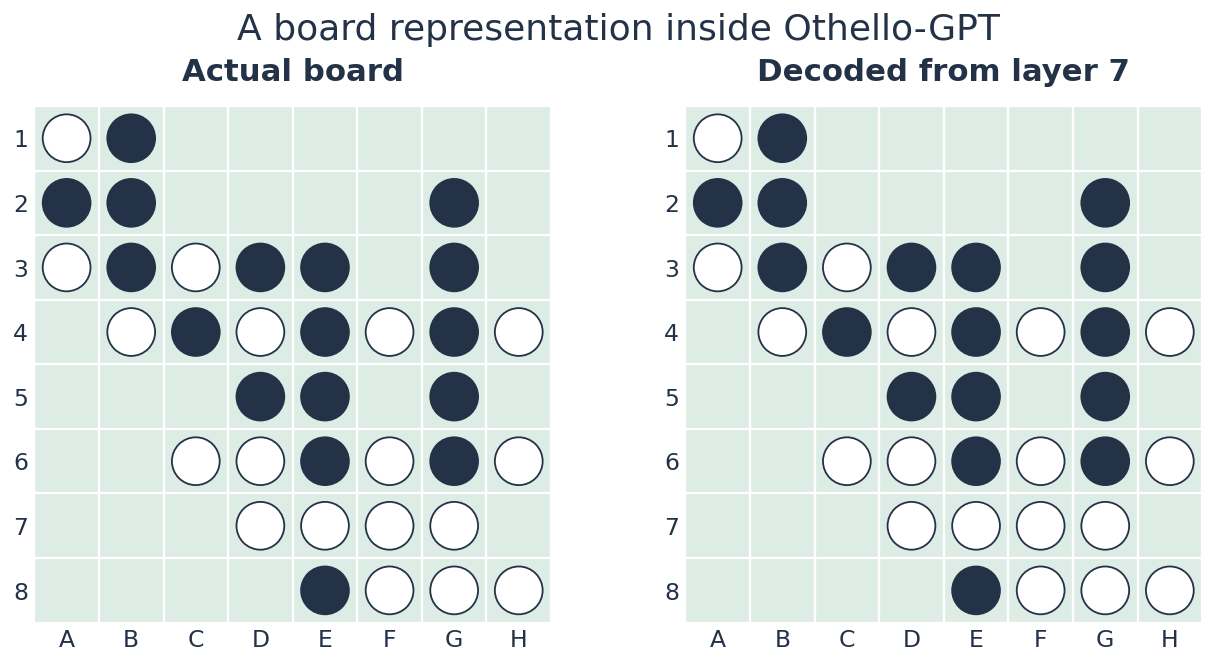

**99.28%** of board squares decoded correctly  ·  **99.93%** legal next moves across 5,800 positions

In [15]:
plot_decoded_board(actual_board, decoded_board, cmap)
display(
    Markdown(
        f"**{designated_accuracy:.2%}** of board squares decoded correctly  ·  "
        f"**{legal_rate:.2%}** legal next moves across {total:,} positions"
    )
)

## Diagnostic: constructing an activation replacement

This section checks two implementation details: a fixed probe-direction edit agrees
with a reference hook, and an optimized activation can satisfy a probe objective.
These are separate checks, not evidence of a behavioral effect. The complete
behavioral workflow appears in the next section.

In [16]:
game = games_int[8:9, :51]
position, layer, row, column, scale = 50, 3, 7, 4, 4
direction = probe[0, :, row, column, 2] - probe[0, :, row, column, 1]
direction = direction / direction.norm()
position_target = Target(f"blocks.{layer}.hook_resid_post", "activation", -2, (position,))
activation_key = ("activations", "selected", position_target.module_path)
construct_replacement = TensorDictModule(
    lambda activation: activation - (scale + 1) * (activation @ direction).unsqueeze(-1) * direction,
    in_keys=[activation_key],
    out_keys=[("interventions", "replacement")],
)

One workflow now carries the selected activation through replacement construction, intervention, and scoring. The intervention step consumes the replacement key directly.

In [17]:
def apply_replacement(inputs, value):
    method = SteeringVectors([position_target], lambda **_: value)
    with torch.inference_mode(), method.prepare(model) as hooked:
        return hooked(TensorDict({"input": inputs}, batch_size=[]))["output"]

In [18]:
intervention_workflow = Workflow(
    ActivationCaching(position_target, cache_key=("activations", "selected")),
    construct_replacement,
    TensorDictModule(
        apply_replacement, in_keys=["input", ("interventions", "replacement")], out_keys=[("interventions", "logits")]
    ),
    TensorDictModule(
        lambda output: output.log_softmax(-1),
        in_keys=[("interventions", "logits")],
        out_keys=[("metrics", "log_probabilities")],
    ),
)

In [19]:
with torch.inference_mode():
    intervention = intervention_workflow(model, TensorDict({"input": game}, batch_size=[]))
activation = intervention[activation_key]
replacement = intervention["interventions", "replacement"]
tdhook_log_probs = intervention["metrics", "log_probabilities"]

In [20]:
def reference_hook(residual, hook):
    coefficient = residual[0, position] @ direction
    residual[0, position] -= (scale + 1) * coefficient * direction

In [21]:
with torch.inference_mode():
    reference_log_probs = model.run_with_hooks(
        game, fwd_hooks=[(f"blocks.{layer}.hook_resid_post", reference_hook)]
    ).log_softmax(-1)
max_abs_difference = float((tdhook_log_probs - reference_log_probs).abs().max().cpu())
probe_mode = 1 if position % 2 == 0 else 0
target_board = labels[8, position].clone()
target_board[row, column] = 1 if target_board[row, column] != 1 else 2

In [22]:
def probe_board_objective(_model_output, intervention):
    board_logits = torch.einsum("...d,drco->...rco", intervention, probe[probe_mode])
    desired = target_board.expand(*intervention.shape[:-1], 8, 8)
    probe_loss = F.cross_entropy(board_logits.flatten(0, -2), desired.flatten())
    return InterventionObjective(probe_loss, {"probe_cross_entropy": probe_loss})

In [23]:
def optimize_board_intervention(model, game, position_target, probe_board_objective):
    """Optimize the selected activation with the fixed reproduction settings."""
    optimized = optimize_intervention(
        model,
        (game,),
        InterventionSpec(
            position_target,
            probe_board_objective,
            "linear-probe board cross-entropy",
            max_steps=300,
            optimizer=OptimizerConfig("adam", 5e-2),
            early_stopping=EarlyStoppingConfig(objective_threshold=0.05, min_delta=1e-5, patience=30),
            preservation_regularizer=lambda value, reference: 1e-4 * (value - reference).square().mean(),
        ),
        seed=44,
    )
    return optimized

In [24]:
def optimize_board(inputs):
    result = optimize_board_intervention(model, inputs, position_target, probe_board_objective)
    return NonTensorData(result)


def decode_optimized_board(result):
    value = result.interventions[0].value
    with torch.inference_mode():
        return torch.einsum("...d,drco->...rco", value, probe[probe_mode]).argmax(-1)[0, 0].cpu()

In [25]:
optimization_workflow = Workflow(
    TensorDictModule(optimize_board, ["input"], [("interventions", "optimized")]),
    TensorDictModule(decode_optimized_board, [("interventions", "optimized")], [("views", "optimized_board")]),
)
optimization_result = optimization_workflow(model, TensorDict({"input": game}, []))
optimized = optimization_result["interventions", "optimized"]
optimized_board = optimization_result["views", "optimized_board"]
with torch.inference_mode():
    before_board = torch.einsum("...d,drco->...rco", activation, probe[probe_mode]).argmax(-1)[0, 0].cpu()

In [26]:
def plot_board_intervention(before_board, target_board, optimized_board, row, column, cmap):
    with plt.rc_context(STYLE):
        figure, axes = plt.subplots(1, 3, figsize=(13, 4.8), constrained_layout=True)
        for axis, board, title in zip(
            axes,
            (before_board, target_board.cpu(), optimized_board),
            ("Before intervention", "Requested board", "After optimization"),
        ):
            draw_board(axis, board, title, highlight=(row, column))
        figure.suptitle(f"Editing the decoded board · square {'ABCDEFGH'[column]}{row + 1}", fontsize=20)
        finish_figure(figure, "othello-board-intervention")

In [27]:
display(
    Markdown(
        f"Probe-objective diagnostic: {optimized.stages[0].steps_completed} optimization steps. "
        f"Separate fixed-edit hook check: maximum log-probability difference {max_abs_difference:.1e}."
    )
)

Probe-objective diagnostic: 4 optimization steps. Separate fixed-edit hook check: maximum log-probability difference 0.0e+00.

## Change the represented board, then measure behavior

Can an internal edit make the model's predictions for move B resemble those for
move A? We use the released Hazineh model and probes, with game 0, ten moves played,
layer 4, and the first two legal options fixed before measuring effects.

The target is the board **decoded from option A's activation**, not an arbitrary
collection of flipped squares. Starting from B's activation, optimization finds a
replacement matching that target. The model weights and probe remain fixed.

The workflow captures both options, constructs replacements, applies the edit and
controls, and compares predictions. Every intermediate passes through named keys.
This is a single-example adaptation of the Figure 4 experiment, not a new aggregate
reproduction claim. The full sweep below provides the broader evaluation.

In [28]:
from othello_figure4 import (
    prepare_behavior_example,
    option_intervention_workflow,
    prediction_view,
    plot_prediction_comparison,
    _randomized_probe,
)

behavior_model, behavior_probe, behavior_inputs = prepare_behavior_example(
    CACHE,
    games_int.detach().cpu().numpy(),
    games_string,
    othello,
    game_index=0,
    game_length=10,
    layer=3,
)

In [29]:
# The eight stages include reference/alternative capture, inverse mapping,
# edit/sham/random-probe/wrong-layer runs, and cosine-similarity scoring.
comparison = option_intervention_workflow(
    behavior_model, 3, behavior_probe, _randomized_probe(behavior_probe, 3, seed=44)
)
behavior_workflow = Workflow(
    *comparison.steps,
    TensorDictModule(
        prediction_view,
        in_keys=[("logits", name) for name in ("reference", "clean", "intervention", "sham")]
        + [("metrics", "scores")],
        out_keys=[("views", "prediction_comparison")],
    ),
)

In [30]:
behavior_result = behavior_workflow(behavior_model, behavior_inputs)
behavior_view = behavior_result["views", "prediction_comparison"]
behavior_view["configuration"] = {
    "game_index": 0,
    "game_length": 10,
    "layer": 4,
    "reference_tokens": behavior_inputs["reference_input"].cpu().tolist(),
    "alternative_tokens": behavior_inputs["alternative_input"].cpu().tolist(),
}
Path("figures").mkdir(exist_ok=True)
Path("figures/othello-prediction-comparison.json").write_text(json.dumps(behavior_view, indent=2))

6077

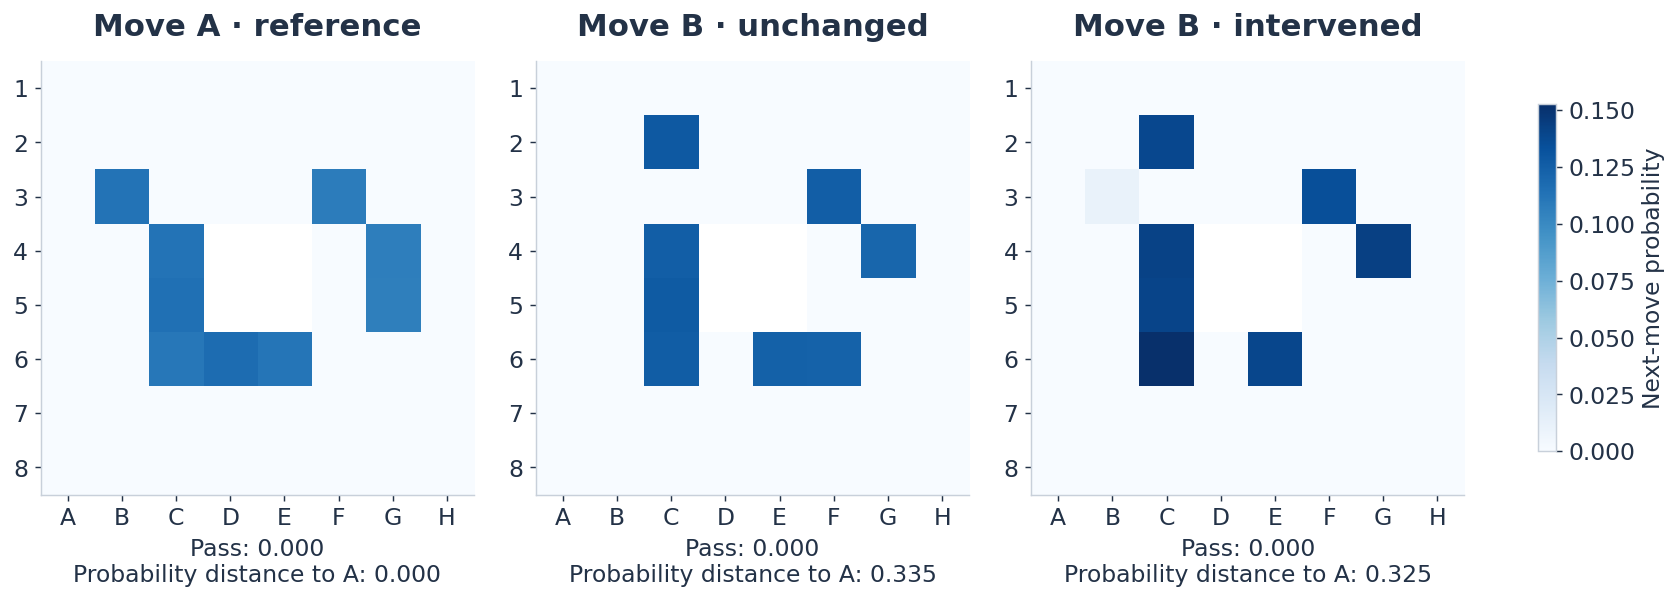

Logit cosine similarity to A: **0.668 → 0.833**. Sham: 0.668; wrong layer: 0.684; random probe: 0.691. Sham maximum logit difference: 0.0e+00.

In [31]:
# This cell can be rerun from JSON without a model or optimization.
saved_view = json.loads(Path("figures/othello-prediction-comparison.json").read_text())
finish_figure(plot_prediction_comparison(saved_view), "othello-prediction-comparison")
scores = saved_view["scores"]
display(
    Markdown(
        f"Logit cosine similarity to A: **{scores['clean']:.3f} → {scores['intervention']:.3f}**. "
        f"Sham: {scores['sham']:.3f}; wrong layer: {scores['wrong_layer']:.3f}; "
        f"random probe: {scores['randomized_probe']:.3f}. "
        f"Sham maximum logit difference: {saved_view['sham_max_abs_logit_difference']:.1e}."
    )
)

The maps show probabilities on a shared scale; the score compares logits,
as in the paper. A successful edit increases similarity to A, but the selected
example is reported even if it does not. Centers are masked because they have no
move token; pass probability is reported separately. The controls distinguish the
board-informed edit from no-op, wrong-layer, and randomized-probe replacements.

**Composition boundary:** all model executions and optimization finish before
`views/prediction_comparison` is returned. The figure reads only serialized data.

## Across the model

Now we repeat the paper's intervention across 50 games, all eight layers, and several game lengths. The controls use the wrong layer, a randomized probe, or a no-op replacement.

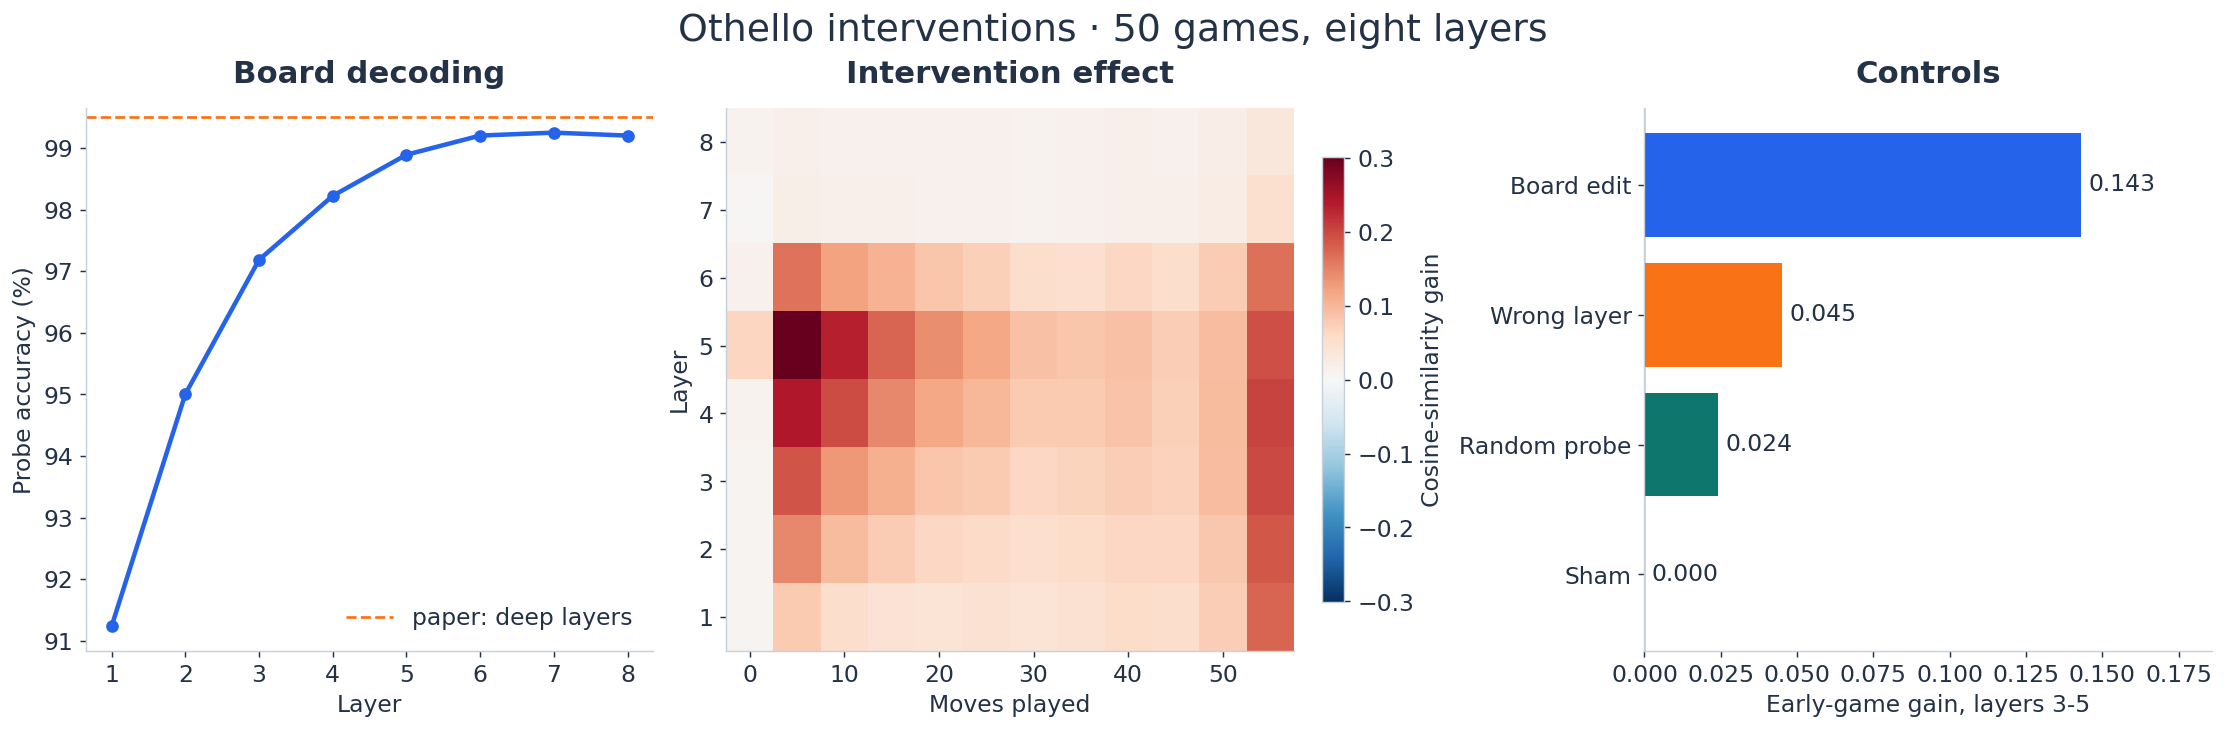

In the early game, editing middle layers has **0.130** more effect than editing late layers (95% bootstrap interval **0.125–0.136**).

In [32]:
from othello_figure4 import plot_figure4_reproduction, run_figure4_reproduction

figure4 = run_figure4_reproduction(
    cache=CACHE,
    games_int=games_int.detach().cpu().numpy(),
    games_string=games_string,
    othello=othello,
    number_games=50,
    seed=44,
)

Path("figures").mkdir(exist_ok=True)
Path("figures/othello-results.json").write_text(json.dumps(figure4, indent=2))
figure = plot_figure4_reproduction(figure4)
finish_figure(figure, "othello-intervention-controls")
ordering = figure4["middle_over_late"]
lower, upper = ordering["interval"]
display(
    Markdown(
        f"In the early game, editing middle layers has **{ordering['mean']:.3f}** more "
        f"effect than editing late layers (95% bootstrap interval **{lower:.3f}–{upper:.3f}**)."
    )
)

## Takeaway

The model's residual stream contains a board representation that becomes sharply readable in later layers. Editing that representation changes move predictions most strongly in the middle of the network, while the sham and randomized controls stay near zero—the same qualitative pattern as Figure 4.

## Evaluation scope

The decoding baseline uses 100 games; the intervention/control sweep uses 50.
The main comparison targets the board decoded from the reference move's activation.
The earlier probe-only diagnostic instead targets the simulator board with E8 flipped;
it can also correct pre-existing decoding errors and is not a behavioral result.
Disc colors follow the simulator (+1 black, -1 white). Probability distance is total
variation over all 61 tokens, including pass. The intervention heatmap uses a symmetric
scale around zero. `figures/othello-results.json` stores the numerical report
and bootstrap intervals for replotting without another model run.
